In [ ]:
import sklearn

In [ ]:
import pandas as pd
import numpy as np
import json
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error as rmse, f1_score as f1, accuracy_score as acc, precision_score as pr, recall_score as rc, mean_squared_error as mse
import math

In [ ]:
import warnings

def fxn():
    warnings.warn("deprecated", DeprecationWarning)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

In [ ]:
dfm1 = pd.read_excel('https://github.com/KSTSV/diploma/raw/main/train_mis_data.xlsx')
dft1 = pd.read_excel('https://github.com/KSTSV/diploma/raw/main/train_data.xlsx')

dfm1 = dfm1[sorted(dfm1.columns)].reset_index(drop = True)
dft1 = dft1[sorted(dfm1.columns)].reset_index(drop = True)

dfm1 = dfm1.drop('Unnamed: 0', axis=1)
dft1 = dft1.drop('Unnamed: 0', axis=1)


dft1 = dft1.astype(float)

dfm1 = dfm1.astype(float)

# dfm = pd.concat([dfm1[cat_ord], dft1[int_cols]], axis=1)
# dfm = dfm[sorted(dft1.columns)]
# dfm

NameError: name 'pd' is not defined

In [ ]:
data_test =  pd.read_excel('https://github.com/KSTSV/diploma/raw/main/%D0%B8%D1%82%D0%BE%D0%B3%D0%BE%D0%B2%D1%8B%D0%B9%20%D0%BC%D0%B0%D1%81%D1%81%D0%B8%D0%B2%20%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.xlsx')
data_test = data_test.drop(['ID', 'town'], axis=1)
data_test = data_test.replace(99999999, np.nan)


data_test = data_test[sorted(dfm1.columns)]


data_test = data_test.astype(float)

NameError: name 'dfm1' is not defined

In [ ]:
cat_cols = ['gndr', 'marital_stat', 'initiative1_employer',
       'initiative2_persona', 'money_what_employer', 'money_what_persona',
       'money_what_free_other', 'is_spec_crs', 'profwrk']

ord_cols = ['edu', 'change_sal',
       'title_wrk', 'incm']

cat_ord = ['gndr', 'marital_stat', 'initiative1_employer',
       'initiative2_persona', 'money_what_employer', 'money_what_persona',
       'money_what_free_other', 'is_spec_crs', 'profwrk', 'edu', 'change_sal',
       'title_wrk', 'incm']

int_ord = ['agea', 'agewrk', 'fctr_succ1', 'fctr_succ2', 'fctr_succ3',
       'fctr_succ4', 'impmot1', 'impmot2', 'impmot3', 'impmot4', 'impmot5',
       'impmot6', 'impmot7', 'impmot8', 'impmot9', 'mot1', 'mot10', 'mot11',
       'mot12', 'mot13', 'mot14', 'mot2', 'mot3', 'mot4', 'mot5', 'mot6',
       'mot7', 'mot8', 'mot9', 'num_crs', 'plcwrk', 'sal', 'sat_wrk', 'edu', 'change_sal',
       'title_wrk', 'incm']

int_cols = dfm1.drop(cat_cols, axis=1).drop(ord_cols, axis=1).columns


miss_vars= ["marital_stat", "num_crs",
            "mot1", "mot2", "mot3", "mot4", "mot5", "mot6", "mot7", "mot8", "mot9", "mot10", "mot11", "mot12", "mot13", "mot14",
            "edu", "agewrk", "plcwrk", "profwrk", "change_sal", "title_wrk", "sal", "sat_wrk",
            "fctr_succ1", "fctr_succ2", "fctr_succ3", "fctr_succ4",
            "impmot1", "impmot2", "impmot3", "impmot4", "impmot5", "impmot6", "impmot7", "impmot8", "impmot9",
            "agea", "incm"]


mcar = ["marital_stat", "num_crs",
        "mot2", "mot6", "mot9", "mot10", "mot11", "mot12", "mot13",
        "agewrk", "plcwrk", "sat_wrk",
        "fctr_succ3", "fctr_succ4",
        "impmot1", "impmot4", "impmot5", "impmot8", "agea", "incm", "title_wrk"]

mar = ["mot1", "mot3", "mot4", "mot5", "mot7", "mot8", "mot14",
       "edu", "profwrk", "change_sal", "sal", "fctr_succ1",
       "fctr_succ2", "impmot2", "impmot3", "impmot6", "impmot7", "impmot9"]


mcar_cat = ['marital_stat']
mcar_ord = ['incm', 'title_wrk']
mcar_int = ['mot2', 'agea', 'mot9', 'fctr_succ4',
            'mot6', 'mot10', 'mot11', 'mot12', 'mot13',
            'impmot1', 'incm', 'impmot4', 'impmot8', 'fctr_succ3', 'agewrk',
            'plcwrk', 'sat_wrk', 'impmot5', 'num_crs']



mar_int = ['impmot2', 'impmot7', 'mot1', 'mot14', 'impmot6', 'mot7', 'mot3', 'fctr_succ2', 'impmot3', 'mot8', 'mot4', 'impmot9', 'mot5', 'sal', 'fctr_succ1']
mar_cat = ['profwrk']
mar_ord = ['edu', 'change_sal']


not_mis = ['gndr', 'initiative1_employer', 'initiative2_persona', 'is_spec_crs',
       'money_what_employer', 'money_what_free_other', 'money_what_persona']


mis_cat_ord = ['marital_stat', 'incm', 'title_wrk', 'profwrk', 'edu', 'change_sal']

In [ ]:
dfm = pd.concat([dfm1[int_cols], dft1[cat_ord]], axis=1)
dfm = dfm[sorted(dft1.columns)]
dfm


,agea,agewrk,change_sal,edu,fctr_succ1,fctr_succ2,fctr_succ3,fctr_succ4,gndr,impmot1,...,mot6,mot7,mot8,mot9,num_crs,plcwrk,profwrk,sal,sat_wrk,title_wrk
0,28.0,5.0,3.0,8.0,2.0,7.0,3.0,6.0,2.0,6.0,...,NaN,6.0,7.0,3.0,NaN,10.0,3.0,29613.0,6.0,1.0
1,49.0,26.0,3.0,7.0,3.0,6.0,2.0,5.0,1.0,3.0,...,3.0,6.0,NaN,6.0,NaN,8.0,6.0,150161.0,4.0,3.0
2,28.0,15.0,3.0,6.0,4.0,4.0,6.0,5.0,1.0,7.0,...,7.0,7.0,7.0,3.0,13.0,9.0,7.0,193605.0,7.0,3.0
3,29.0,6.0,2.0,8.0,7.0,4.0,7.0,7.0,1.0,6.0,...,7.0,7.0,6.0,7.0,NaN,2.0,3.0,63523.0,NaN,3.0
4,30.0,10.0,3.0,8.0,4.0,5.0,4.0,2.0,1.0,6.0,...,1.0,5.0,5.0,2.0,6.0,4.0,3.0,141832.0,6.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
973,50.0,29.0,2.0,7.0,4.0,3.0,3.0,2.0,1.0,5.0,...,1.0,5.0,6.0,2.0,5.0,3.0,7.0,122385.0,6.0,1.0
974,45.0,14.0,3.0,6.0,3.0,5.0,1.0,4.0,2.0,7.0,...,5.0,7.0,6.0,2.0,11.0,5.0,2.0,75924.0,6.0,1.0
975,27.0,8.0,2.0,6.0,3.0,7.0,4.0,5.0,1.0,3.0,...,5.0,NaN,4.0,3.0,2.0,3.0,2.0,171914.0,3.0,1.0
976,38.0,15.0,3.0,7.0,3.0,5.0,3.0,5.0,1.0,6.0,...,1.0,6.0,6.0,1.0,6.0,4.0,1.0,182990.0,5.0,1.0


# GAIN

In [ ]:
from sklearn.preprocessing import StandardScaler
import torch
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

In [ ]:
def GAIN (dft1, dfm1, data_test, int_cols, mb_size, p_hint, alpha, train_rate):
  train_loss = []
  tst_loss = []
    #%% Data
  dfm = pd.concat([dfm1[int_cols], dft1[cat_ord]], axis=1)
  # dfm = pd.concat([dfm1[cat_ord], dft1[int_cols]], axis=1)
  dfm = dfm[sorted(dft1.columns)]

  # Data generation
  Data = np.array(dft1)

  # Parameters
  No = len(Data)
  Dim = len(Data[0,:])

  # Hidden state dimensions
  H_Dim1 = Dim
  H_Dim2 = Dim

  # Normalization (0 to 1)
  Min_Val = np.zeros(Dim)
  Max_Val = np.zeros(Dim)

  for i in range(Dim):
      Min_Val[i] = np.min(Data[:,i])
      Data[:,i] = Data[:,i] - np.min(Data[:,i])
      Max_Val[i] = np.max(Data[:,i])
      Data[:,i] = Data[:,i] / (np.max(Data[:,i]) + 1e-6)

  # %% Missing introducing
  # p_miss_vec = p_miss * np.ones((Dim,1))

  Missing = np.array(dfm.notnull().astype(int))
  Missing_test = np.array(data_test.notnull().astype(int))

  dfm = np.array(dfm)
  dfm = np.where(np.isnan(dfm), np.ma.array(dfm,
                mask = np.isnan(dfm)).mean(axis = 0), dfm)  #заменяем все пропуски на среднее

  # нормализуем массив с пропусками
  Min_Val = np.zeros(Dim)
  Max_Val = np.zeros(Dim)

  for i in range(Dim):
    Min_Val[i] = np.min(dfm[:,i])
    dfm[:,i] = dfm[:,i] - np.min(dfm[:,i])
    Max_Val[i] = np.max(dfm[:,i])
    dfm[:,i] = dfm[:,i] / (np.max(dfm[:,i]) + 1e-6)


  # Train / Test Missing Indicators
  #%% Train Test Division
  Train_No = int(No * train_rate)
  Test_No = No - Train_No
  # Test_No = 255


  idx = np.random.permutation(No)


  trainM = Missing[idx[:Train_No],:]
  testM = Missing[idx[Train_No:],:]
  # testM = np.array(data_test.notnull().astype(int))


  data_test = np.array(data_test)
  data_test = np.where(np.isnan(data_test), np.ma.array(data_test,
                mask = np.isnan(data_test)).mean(axis = 0), data_test)  #заменяем все пропуски на среднее

  # нормализуем массив с пропусками
  Min_Val = np.zeros(Dim)
  Max_Val = np.zeros(Dim)

  for i in range(Dim):
    Min_Val[i] = np.min(data_test[:,i])
    data_test[:,i] = data_test[:,i] - np.min(data_test[:,i])
    Max_Val[i] = np.max(data_test[:,i])
    data_test[:,i] = data_test[:,i] / (np.max(data_test[:,i]) + 1e-6)


  # Train / Test Features
  trainX = Data[idx[:Train_No],:]
  testX = Data[idx[Train_No:],:]
  # testX =  np.array(data_test)




  use_gpu = False  # set it to True to use GPU and False to use CPU
  if use_gpu:
      torch.cuda.set_device(0)

  #%% 1. Discriminator
  global D_W1, D_W2, D_W3, D_b1, D_b2, D_b3
  if use_gpu is True:
      D_W1 = torch.tensor(xavier_init([Dim*2, H_Dim1]),requires_grad=True, device="cuda")     # Data + Hint as inputs
      D_b1 = torch.tensor(np.zeros(shape = [H_Dim1]),requires_grad=True, device="cuda")

      D_W2 = torch.tensor(xavier_init([H_Dim1, H_Dim2]),requires_grad=True, device="cuda")
      D_b2 = torch.tensor(np.zeros(shape = [H_Dim2]),requires_grad=True, device="cuda")

      D_W3 = torch.tensor(xavier_init([H_Dim2, Dim]),requires_grad=True, device="cuda")
      D_b3 = torch.tensor(np.zeros(shape = [Dim]),requires_grad=True, device="cuda")       # Output is multi-variate
  else:
      D_W1 = torch.tensor(xavier_init([Dim*2, H_Dim1]),requires_grad=True)     # Data + Hint as inputs
      D_b1 = torch.tensor(np.zeros(shape = [H_Dim1]),requires_grad=True)

      D_W2 = torch.tensor(xavier_init([H_Dim1, H_Dim2]),requires_grad=True)
      D_b2 = torch.tensor(np.zeros(shape = [H_Dim2]),requires_grad=True)

      D_W3 = torch.tensor(xavier_init([H_Dim2, Dim]),requires_grad=True)
      D_b3 = torch.tensor(np.zeros(shape = [Dim]),requires_grad=True)       # Output is multi-variate

  theta_D = [D_W1, D_W2, D_W3, D_b1, D_b2, D_b3]

  #%% 2. Generator
  global G_W1, G_W2, G_W3, G_b1, G_b2, G_b3
  if use_gpu is True:
      G_W1 = torch.tensor(xavier_init([Dim*2, H_Dim1]),requires_grad=True, device="cuda")     # Data + Mask as inputs (Random Noises are in Missing Components)
      G_b1 = torch.tensor(np.zeros(shape = [H_Dim1]),requires_grad=True, device="cuda")

      G_W2 = torch.tensor(xavier_init([H_Dim1, H_Dim2]),requires_grad=True, device="cuda")
      G_b2 = torch.tensor(np.zeros(shape = [H_Dim2]),requires_grad=True, device="cuda")

      G_W3 = torch.tensor(xavier_init([H_Dim2, Dim]),requires_grad=True, device="cuda")
      G_b3 = torch.tensor(np.zeros(shape = [Dim]),requires_grad=True, device="cuda")
  else:
      G_W1 = torch.tensor(xavier_init([Dim*2, H_Dim1]),requires_grad=True)     # Data + Mask as inputs (Random Noises are in Missing Components)
      G_b1 = torch.tensor(np.zeros(shape = [H_Dim1]),requires_grad=True)

      G_W2 = torch.tensor(xavier_init([H_Dim1, H_Dim2]),requires_grad=True)
      G_b2 = torch.tensor(np.zeros(shape = [H_Dim2]),requires_grad=True)

      G_W3 = torch.tensor(xavier_init([H_Dim2, Dim]),requires_grad=True)
      G_b3 = torch.tensor(np.zeros(shape = [Dim]),requires_grad=True)

  theta_G = [G_W1, G_W2, G_W3, G_b1, G_b2, G_b3]



  optimizer_D = torch.optim.SGD(params=theta_D)
  optimizer_G = torch.optim.SGD(params=theta_G)

  for it in tqdm(range(5000)):

    #%% Inputs
    mb_idx = sample_idx(Train_No, mb_size)
    X_mb = trainX[mb_idx,:]

    Z_mb = sample_Z(mb_size, Dim)
    M_mb = trainM[mb_idx,:]
    H_mb1 = sample_M(mb_size, Dim, 1-p_hint)
    H_mb = M_mb * H_mb1

    New_X_mb = M_mb * X_mb + (1-M_mb) * Z_mb  # Missing Data Introduce

    if use_gpu is True:
        X_mb = torch.tensor(X_mb, device="cuda")
        M_mb = torch.tensor(M_mb, device="cuda")
        H_mb = torch.tensor(H_mb, device="cuda")
        New_X_mb = torch.tensor(New_X_mb, device="cuda")
    else:
        X_mb = torch.tensor(X_mb)
        M_mb = torch.tensor(M_mb)
        H_mb = torch.tensor(H_mb)
        New_X_mb = torch.tensor(New_X_mb)

    optimizer_D.zero_grad()
    D_loss_curr = discriminator_loss(M=M_mb, New_X=New_X_mb, H=H_mb)
    D_loss_curr.backward()
    optimizer_D.step()

    optimizer_G.zero_grad()
    G_loss_curr, MSE_train_loss_curr, MSE_test_loss_curr = generator_loss(X=X_mb, M=M_mb, New_X=New_X_mb, H=H_mb) # , alpha = alpha
    G_loss_curr.backward()
    optimizer_G.step()



    train_loss.append(float(np.sqrt(MSE_train_loss_curr.item())))
    tst_loss.append(float(np.sqrt(MSE_test_loss_curr.item())))

    #%% Intermediate Losses
    if it % 100 == 0:
        print('Iter: {}'.format(it))
        print('Train_loss: {:.4}'.format(np.sqrt(MSE_train_loss_curr.item())))
        # print('Train_loss: {:.4}'.format(MSE_train_loss_curr.item()))
        print('Test_loss: {:.4}'.format(np.sqrt(MSE_test_loss_curr.item())))
        # print('Test_loss: {:.4}'.format(MSE_test_loss_curr.item()))
        print()

    # alpha = alpha*0.99999999
    # print(alpha)


  Z_mb = sample_Z(Test_No, Dim)
  M_mb = testM
  X_mb = testX

  New_X_mb = M_mb * X_mb + (1-M_mb) * Z_mb  # Missing Data Introduce

  if use_gpu is True:
      X_mb = torch.tensor(X_mb, device='cuda')
      M_mb = torch.tensor(M_mb, device='cuda')
      New_X_mb = torch.tensor(New_X_mb, device='cuda')
  else:
      X_mb = torch.tensor(X_mb)
      M_mb = torch.tensor(M_mb)
      New_X_mb = torch.tensor(New_X_mb)

  MSE_final, Sample = test_loss(X=X_mb, M=M_mb, New_X=New_X_mb)

  print('Final Test RMSE: ' + str(np.sqrt(MSE_final.item())))
  # print('Final Test RMSE: ' + str(MSE_final.item()))

  imputed_data_test = M_mb * X_mb + (1-M_mb) * Sample
  print("Imputed test data:")
  # # np.set_printoptions(formatter={'float': lambda x: "{0:0.8f}".format(x)})

  imputed_data_test = imputed_data_test.detach().numpy()
  Data_denorm_test = np.zeros_like(pd.DataFrame(imputed_data_test, columns = dfm1.columns))
  for i in range(Dim):
    Data_denorm_test[:,i] = imputed_data_test[:,i] * (Max_Val[i] + 1e-6) + Min_Val[i]

  denom_test = pd.DataFrame(Data_denorm_test, columns = dfm1.columns)

  Z_mb = sample_Z(255, Dim)
  M_mb = Missing_test
  X_mb = data_test # dfm

  New_X_mb = M_mb * X_mb + (1-M_mb) * Z_mb  # Missing Data Introduce

  if use_gpu is True:
      X_mb = torch.tensor(X_mb, device='cuda')
      M_mb = torch.tensor(M_mb, device='cuda')
      New_X_mb = torch.tensor(New_X_mb, device='cuda')
  else:
      X_mb = torch.tensor(X_mb)
      M_mb = torch.tensor(M_mb)
      New_X_mb = torch.tensor(New_X_mb)

  MSE_final, Sample = test_loss(X=X_mb, M=M_mb, New_X=New_X_mb)

  imputed_data = M_mb * X_mb + (1-M_mb) * Sample
  imputed_data = imputed_data.detach().numpy()

  Data_denorm = np.zeros_like(pd.DataFrame(imputed_data, columns = dfm1.columns))

  for i in range(Dim):
    Data_denorm[:,i] = imputed_data[:,i] * (Max_Val[i] + 1e-6) + Min_Val[i]
  denom = pd.DataFrame(Data_denorm, columns = dfm1.columns)





  # denom[int_cols] = sc.inverse_transform(denom[int_cols])

  return denom, np.sqrt(MSE_final.item()), train_loss, tst_loss #imputed_data_test #denom

In [ ]:

# Data = np.array(dft1)

# # Parameters
# No = len(Data)
# Dim = len(Data[0,:])

# # Hidden state dimensions
# H_Dim1 = Dim
# H_Dim2 = Dim

# # Normalization (0 to 1)
# Min_Val = np.zeros(Dim)
# Max_Val = np.zeros(Dim)

# for i in range(Dim):
#     Min_Val[i] = np.min(Data[:,i])
#     Data[:,i] = Data[:,i] - np.min(Data[:,i])
#     Max_Val[i] = np.max(Data[:,i])
#     Data[:,i] = Data[:,i] / (np.max(Data[:,i]) + 1e-6)




# Missing = np.array(dfm.notnull().astype(int))


# #%% Train Test Division
# train_rate = 0.90
# idx = np.random.permutation(No)
# Train_No = int(No * train_rate)
# # Test_No = No - Train_No
# Test_No = 255



# # Train / Test Missing Indicators
# trainM = Missing[idx[:Train_No],:]
# # testM = Missing[idx[Train_No:],:]
# testM = np.array(data_test.notnull().astype(int))


# data_test1 = np.array(data_test)
# data_test1 = np.where(np.isnan(data_test), np.ma.array(data_test,
#             mask = np.isnan(data_test)).mean(axis = 0), data_test)  #заменяем все пропуски на среднее



# # Train / Test Features
# trainX = Data[idx[:Train_No],:]
# # testX = Data[idx[Train_No:],:]
# testX =  np.array(data_test1)

# #%% Necessary Functions

def xavier_init(size):
    in_dim = size[0]
    xavier_stddev = 1. / np.sqrt(in_dim / 2.)
    return np.random.normal(size = size, scale = xavier_stddev)

# Hint Vector Generation
def sample_M(m, n, p):
    A = np.random.uniform(0., 1., size = [m, n])
    B = A > p
    C = 1.*B
    return C

use_gpu = False

In [ ]:
def generator(new_x,m):

    inputs = torch.cat(dim = 1, tensors = [new_x,m])  # Mask + Data Concatenate
    G_h1 = F.leaky_relu(torch.matmul(inputs, G_W1) + G_b1)
    # G_h1 = F.batch_norm(G_h1)
    G_h1_drop = F.dropout(G_h1, p=0.2, training=True)
    G_h2 = F.relu(torch.matmul(G_h1_drop, G_W2) + G_b2)
    # G_h1 = F.batch_norm(G_h2)
    # G_prob = torch.sigmoid(torch.matmul(G_h2, G_W3) + G_b3) # [0,1] normalized Output
    G_prob = torch.sigmoid(torch.matmul(G_h2, G_W3) + G_b3) # [0,1] normalized Output

    return G_prob

#%% 2. Discriminator
def discriminator(new_x, h):

    inputs = torch.cat(dim = 1, tensors = [new_x,h])  # Hint + Data Concatenate
    D_h1 = F.relu(torch.matmul(inputs, D_W1) + D_b1)
    D_h1_drop = F.dropout(D_h1, p=0.6, training=True)

    D_h2 = F.relu(torch.matmul(D_h1, D_W2) + D_b2)
    D_logit = torch.matmul(D_h2, D_W3) + D_b3
    D_prob = torch.sigmoid(D_logit)  # [0,1] Probability Output

    return D_prob

#%% 3. Other functions
# Random sample generator for Z
def sample_Z(m, n):
    return np.random.uniform(0., 0.01, size = [m, n])

# Mini-batch generation
def sample_idx(m, n):
    A = np.random.permutation(m)
    idx = A[:n]
    return idx


def discriminator_loss(M, New_X, H):
    # Generator
    G_sample = generator(New_X,M)
    # Combine with original data
    Hat_New_X = New_X * M + G_sample * (1-M)

    # Discriminator
    D_prob = discriminator(Hat_New_X, H)

    #%% Loss
    D_loss = -torch.mean(M * torch.log(D_prob + 1e-8) + (1-M) * torch.log(1. - D_prob + 1e-8), dtype=torch.float32)
    return D_loss

def generator_loss(X, M, New_X, H):
    #%% Structure
    # Generator

    G_sample = generator(New_X,M)

    # Combine with original data
    Hat_New_X = New_X * M + G_sample * (1-M)

    # Discriminator
    D_prob = discriminator(Hat_New_X, H)

    #%% Loss
    G_loss1 = -torch.mean((1-M) * torch.log(D_prob + 1e-8), dtype=torch.float32)
    MSE_train_loss = torch.mean((M * New_X - M * G_sample)**2, dtype=torch.float32) / torch.mean(M, dtype=torch.float32)
    # t = ((M) * X)
    # p = ((M)*G_sample)
    # MSE_train_loss = ((((t-p).abs() <= 0.3) * (M)).sum() /  (M).sum())

    # G_loss = G_loss1 + alpha*0.2 * (1/MSE_train_loss) + alpha*0.8 * MSE_train_loss1

    G_loss = G_loss1 + alpha* MSE_train_loss
    # alpha = alpha*0.9

    #%% MSE Performance metric
    MSE_test_loss = torch.mean(((1-M) * X - (1-M)*G_sample)**2, dtype=torch.float32) / torch.mean(1-M, dtype=torch.float32)

    # t = ((1-M) * X)
    # p = ((1-M)*G_sample)
    # MSE_test_loss = (((t-p).abs() < 1) * (M)).sum() /  (M+(1-M)).sum()
    # MSE_test_loss = ((((t-p).abs() <= 0.3) * (1-M)).sum() /  (1-M).sum())

    return G_loss, MSE_train_loss, MSE_test_loss

def test_loss(X, M, New_X):
    #%% Structure
    # Generator
    G_sample = generator(New_X,M)

    #%% MSE Performance metric
    MSE_test_loss = torch.mean(((1-M) * X - (1-M)*G_sample)**2, dtype=torch.float32) / torch.mean(1-M, dtype=torch.float32)
    # t = ((1-M) * X)
    # p = ((1-M) * G_sample)

    # MSE_test_loss = ((((t-p).abs() <= 0.3) * (1-M)).sum() /  (1-M).sum())
    # MSE_test_loss = f1(t, p, average = 'macro')

    return MSE_test_loss, G_sample

def xavier_init(size):
    in_dim = size[0]
    xavier_stddev = 1. / np.sqrt(in_dim / 2.)
    return np.random.normal(size = size, scale = xavier_stddev)

# Hint Vector Generation
def sample_M(m, n, p):
    A = np.random.uniform(0., 1., size = [m, n])
    B = A > p
    C = 1.*B
    return C

In [ ]:
def round_(x):
    return np.where(x % 1 >= 0.5, np.ceil(x), np.floor(x))

In [ ]:
mb_size = 128
p_hint = 0.8
alpha = 2000
train_rate = 0.9

d = GAIN(dft1, dfm1, data_test, int_cols, mb_size, p_hint, alpha, train_rate)

  1%|          | 33/5000 [00:00<00:31, 158.46it/s]

Iter: 0
Train_loss: 0.4928
Test_loss: 0.4312



  3%|▎         | 130/5000 [00:00<00:32, 150.00it/s]

Iter: 100
Train_loss: 0.2895
Test_loss: 0.3007



  5%|▍         | 229/5000 [00:01<00:30, 157.88it/s]

...

Iter: 4800
Train_loss: 0.1711
Test_loss: 0.2843



 99%|█████████▊| 4928/5000 [00:35<00:00, 157.34it/s]

Iter: 4900
Train_loss: 0.1643
Test_loss: 0.3096



100%|██████████| 5000/5000 [00:35<00:00, 140.33it/s]

Final Test RMSE: 0.2827554650516365
Imputed test data:


In [ ]:
df_int_cols = d[0][int_cols]

# Категориальные

In [ ]:
def GAIN (dft1, dfm1, data_test, int_cols, mb_size, p_hint, alpha, train_rate):
  train_loss = []
  tst_loss = []
    #%% Data
  # dfm = pd.concat([dfm1[int_cols], dft1[cat_ord]], axis=1)
  dfm = pd.concat([dfm1[cat_ord], dft1[int_cols]], axis=1)
  dfm = dfm[sorted(dft1.columns)]

  # Data generation
  Data = np.array(dft1)

  # Parameters
  No = len(Data)
  Dim = len(Data[0,:])

  # Hidden state dimensions
  H_Dim1 = Dim
  H_Dim2 = Dim

  # Normalization (0 to 1)
  Min_Val = np.zeros(Dim)
  Max_Val = np.zeros(Dim)

  for i in range(Dim):
      Min_Val[i] = np.min(Data[:,i])
      Data[:,i] = Data[:,i] - np.min(Data[:,i])
      Max_Val[i] = np.max(Data[:,i])
      Data[:,i] = Data[:,i] / (np.max(Data[:,i]) + 1e-6)

  # %% Missing introducing
  # p_miss_vec = p_miss * np.ones((Dim,1))

  Missing = np.array(dfm.notnull().astype(int))
  Missing_test = np.array(data_test.notnull().astype(int))

  dfm = np.array(dfm)
  dfm = np.where(np.isnan(dfm), np.ma.array(dfm,
                mask = np.isnan(dfm)).mean(axis = 0), dfm)  #заменяем все пропуски на среднее

  # нормализуем массив с пропусками
  Min_Val = np.zeros(Dim)
  Max_Val = np.zeros(Dim)

  for i in range(Dim):
    Min_Val[i] = np.min(dfm[:,i])
    dfm[:,i] = dfm[:,i] - np.min(dfm[:,i])
    Max_Val[i] = np.max(dfm[:,i])
    dfm[:,i] = dfm[:,i] / (np.max(dfm[:,i]) + 1e-6)


  # Train / Test Missing Indicators
  #%% Train Test Division
  Train_No = int(No * train_rate)
  Test_No = No - Train_No
  # Test_No = 255


  idx = np.random.permutation(No)


  trainM = Missing[idx[:Train_No],:]
  testM = Missing[idx[Train_No:],:]
  # testM = np.array(data_test.notnull().astype(int))


  data_test = np.array(data_test)
  data_test = np.where(np.isnan(data_test), np.ma.array(data_test,
                mask = np.isnan(data_test)).mean(axis = 0), data_test)  #заменяем все пропуски на среднее

  # нормализуем массив с пропусками
  Min_Val = np.zeros(Dim)
  Max_Val = np.zeros(Dim)

  for i in range(Dim):
    Min_Val[i] = np.min(data_test[:,i])
    data_test[:,i] = data_test[:,i] - np.min(data_test[:,i])
    Max_Val[i] = np.max(data_test[:,i])
    data_test[:,i] = data_test[:,i] / (np.max(data_test[:,i]) + 1e-6)


  # Train / Test Features
  trainX = Data[idx[:Train_No],:]
  testX = Data[idx[Train_No:],:]
  # testX =  np.array(data_test)




  use_gpu = False  # set it to True to use GPU and False to use CPU
  if use_gpu:
      torch.cuda.set_device(0)

  #%% 1. Discriminator
  global D_W1, D_W2, D_W3, D_b1, D_b2, D_b3
  if use_gpu is True:
      D_W1 = torch.tensor(xavier_init([Dim*2, H_Dim1]),requires_grad=True, device="cuda")     # Data + Hint as inputs
      D_b1 = torch.tensor(np.zeros(shape = [H_Dim1]),requires_grad=True, device="cuda")

      D_W2 = torch.tensor(xavier_init([H_Dim1, H_Dim2]),requires_grad=True, device="cuda")
      D_b2 = torch.tensor(np.zeros(shape = [H_Dim2]),requires_grad=True, device="cuda")

      D_W3 = torch.tensor(xavier_init([H_Dim2, Dim]),requires_grad=True, device="cuda")
      D_b3 = torch.tensor(np.zeros(shape = [Dim]),requires_grad=True, device="cuda")       # Output is multi-variate
  else:
      D_W1 = torch.tensor(xavier_init([Dim*2, H_Dim1]),requires_grad=True)     # Data + Hint as inputs
      D_b1 = torch.tensor(np.zeros(shape = [H_Dim1]),requires_grad=True)

      D_W2 = torch.tensor(xavier_init([H_Dim1, H_Dim2]),requires_grad=True)
      D_b2 = torch.tensor(np.zeros(shape = [H_Dim2]),requires_grad=True)

      D_W3 = torch.tensor(xavier_init([H_Dim2, Dim]),requires_grad=True)
      D_b3 = torch.tensor(np.zeros(shape = [Dim]),requires_grad=True)       # Output is multi-variate

  theta_D = [D_W1, D_W2, D_W3, D_b1, D_b2, D_b3]

  #%% 2. Generator
  global G_W1, G_W2, G_W3, G_b1, G_b2, G_b3
  if use_gpu is True:
      G_W1 = torch.tensor(xavier_init([Dim*2, H_Dim1]),requires_grad=True, device="cuda")     # Data + Mask as inputs (Random Noises are in Missing Components)
      G_b1 = torch.tensor(np.zeros(shape = [H_Dim1]),requires_grad=True, device="cuda")

      G_W2 = torch.tensor(xavier_init([H_Dim1, H_Dim2]),requires_grad=True, device="cuda")
      G_b2 = torch.tensor(np.zeros(shape = [H_Dim2]),requires_grad=True, device="cuda")

      G_W3 = torch.tensor(xavier_init([H_Dim2, Dim]),requires_grad=True, device="cuda")
      G_b3 = torch.tensor(np.zeros(shape = [Dim]),requires_grad=True, device="cuda")
  else:
      G_W1 = torch.tensor(xavier_init([Dim*2, H_Dim1]),requires_grad=True)     # Data + Mask as inputs (Random Noises are in Missing Components)
      G_b1 = torch.tensor(np.zeros(shape = [H_Dim1]),requires_grad=True)

      G_W2 = torch.tensor(xavier_init([H_Dim1, H_Dim2]),requires_grad=True)
      G_b2 = torch.tensor(np.zeros(shape = [H_Dim2]),requires_grad=True)

      G_W3 = torch.tensor(xavier_init([H_Dim2, Dim]),requires_grad=True)
      G_b3 = torch.tensor(np.zeros(shape = [Dim]),requires_grad=True)

  theta_G = [G_W1, G_W2, G_W3, G_b1, G_b2, G_b3]



  optimizer_D = torch.optim.SGD(params=theta_D)
  optimizer_G = torch.optim.SGD(params=theta_G)

  for it in tqdm(range(5000)):

    #%% Inputs
    mb_idx = sample_idx(Train_No, mb_size)
    X_mb = trainX[mb_idx,:]

    Z_mb = sample_Z(mb_size, Dim)
    M_mb = trainM[mb_idx,:]
    H_mb1 = sample_M(mb_size, Dim, 1-p_hint)
    H_mb = M_mb * H_mb1

    New_X_mb = M_mb * X_mb + (1-M_mb) * Z_mb  # Missing Data Introduce

    if use_gpu is True:
        X_mb = torch.tensor(X_mb, device="cuda")
        M_mb = torch.tensor(M_mb, device="cuda")
        H_mb = torch.tensor(H_mb, device="cuda")
        New_X_mb = torch.tensor(New_X_mb, device="cuda")
    else:
        X_mb = torch.tensor(X_mb)
        M_mb = torch.tensor(M_mb)
        H_mb = torch.tensor(H_mb)
        New_X_mb = torch.tensor(New_X_mb)

    optimizer_D.zero_grad()
    D_loss_curr = discriminator_loss(M=M_mb, New_X=New_X_mb, H=H_mb)
    D_loss_curr.backward()
    optimizer_D.step()

    optimizer_G.zero_grad()
    G_loss_curr, MSE_train_loss_curr, MSE_test_loss_curr = generator_loss(X=X_mb, M=M_mb, New_X=New_X_mb, H=H_mb) # , alpha = alpha
    G_loss_curr.backward()
    optimizer_G.step()



    train_loss.append(float(np.sqrt(MSE_train_loss_curr.item())))
    tst_loss.append(float(np.sqrt(MSE_test_loss_curr.item())))

    #%% Intermediate Losses
    if it % 100 == 0:
        print('Iter: {}'.format(it))
        # print('Train_loss: {:.4}'.format(np.sqrt(MSE_train_loss_curr.item())))
        print('Train_loss: {:.4}'.format(MSE_train_loss_curr.item()))
        # print('Test_loss: {:.4}'.format(np.sqrt(MSE_test_loss_curr.item())))
        print('Test_loss: {:.4}'.format(MSE_test_loss_curr.item()))
        print()

    # alpha = alpha*0.99999999
    # print(alpha)


  Z_mb = sample_Z(Test_No, Dim)
  M_mb = testM
  X_mb = testX

  New_X_mb = M_mb * X_mb + (1-M_mb) * Z_mb  # Missing Data Introduce

  if use_gpu is True:
      X_mb = torch.tensor(X_mb, device='cuda')
      M_mb = torch.tensor(M_mb, device='cuda')
      New_X_mb = torch.tensor(New_X_mb, device='cuda')
  else:
      X_mb = torch.tensor(X_mb)
      M_mb = torch.tensor(M_mb)
      New_X_mb = torch.tensor(New_X_mb)

  MSE_final, Sample = test_loss(X=X_mb, M=M_mb, New_X=New_X_mb)

  # print('Final Test RMSE: ' + str(np.sqrt(MSE_final.item())))
  print('Final Test RMSE: ' + str(MSE_final.item()))

  imputed_data_test = M_mb * X_mb + (1-M_mb) * Sample
  print("Imputed test data:")
  # # np.set_printoptions(formatter={'float': lambda x: "{0:0.8f}".format(x)})

  imputed_data_test = imputed_data_test.detach().numpy()
  Data_denorm_test = np.zeros_like(pd.DataFrame(imputed_data_test, columns = dfm1.columns))
  for i in range(Dim):
    Data_denorm_test[:,i] = imputed_data_test[:,i] * (Max_Val[i] + 1e-6) + Min_Val[i]

  denom_test = pd.DataFrame(Data_denorm_test, columns = dfm1.columns)

  Z_mb = sample_Z(255, Dim)
  M_mb = Missing_test
  X_mb = data_test # dfm

  New_X_mb = M_mb * X_mb + (1-M_mb) * Z_mb  # Missing Data Introduce

  if use_gpu is True:
      X_mb = torch.tensor(X_mb, device='cuda')
      M_mb = torch.tensor(M_mb, device='cuda')
      New_X_mb = torch.tensor(New_X_mb, device='cuda')
  else:
      X_mb = torch.tensor(X_mb)
      M_mb = torch.tensor(M_mb)
      New_X_mb = torch.tensor(New_X_mb)

  MSE_final, Sample = test_loss(X=X_mb, M=M_mb, New_X=New_X_mb)

  imputed_data = M_mb * X_mb + (1-M_mb) * Sample
  imputed_data = imputed_data.detach().numpy()

  Data_denorm = np.zeros_like(pd.DataFrame(imputed_data, columns = dfm1.columns))

  for i in range(Dim):
    Data_denorm[:,i] = imputed_data[:,i] * (Max_Val[i] + 1e-6) + Min_Val[i]
  denom = pd.DataFrame(Data_denorm, columns = dfm1.columns)





  # denom[int_cols] = sc.inverse_transform(denom[int_cols])

  return denom, np.sqrt(MSE_final.item()), train_loss, tst_loss #imputed_data_test #denom

In [ ]:

# Data = np.array(dft1)

# # Parameters
# No = len(Data)
# Dim = len(Data[0,:])

# # Hidden state dimensions
# H_Dim1 = Dim
# H_Dim2 = Dim

# # Normalization (0 to 1)
# Min_Val = np.zeros(Dim)
# Max_Val = np.zeros(Dim)

# for i in range(Dim):
#     Min_Val[i] = np.min(Data[:,i])
#     Data[:,i] = Data[:,i] - np.min(Data[:,i])
#     Max_Val[i] = np.max(Data[:,i])
#     Data[:,i] = Data[:,i] / (np.max(Data[:,i]) + 1e-6)




# Missing = np.array(dfm.notnull().astype(int))


# #%% Train Test Division
# train_rate = 0.90
# idx = np.random.permutation(No)
# Train_No = int(No * train_rate)
# # Test_No = No - Train_No
# Test_No = 255



# # Train / Test Missing Indicators
# trainM = Missing[idx[:Train_No],:]
# # testM = Missing[idx[Train_No:],:]
# testM = np.array(data_test.notnull().astype(int))


# data_test1 = np.array(data_test)
# data_test1 = np.where(np.isnan(data_test), np.ma.array(data_test,
#             mask = np.isnan(data_test)).mean(axis = 0), data_test)  #заменяем все пропуски на среднее



# # Train / Test Features
# trainX = Data[idx[:Train_No],:]
# # testX = Data[idx[Train_No:],:]
# testX =  np.array(data_test1)

# #%% Necessary Functions

def xavier_init(size):
    in_dim = size[0]
    xavier_stddev = 1. / np.sqrt(in_dim / 2.)
    return np.random.normal(size = size, scale = xavier_stddev)

# Hint Vector Generation
def sample_M(m, n, p):
    A = np.random.uniform(0., 1., size = [m, n])
    B = A > p
    C = 1.*B
    return C

use_gpu = False

In [ ]:
def generator(new_x,m):

    inputs = torch.cat(dim = 1, tensors = [new_x,m])  # Mask + Data Concatenate
    G_h1 = F.leaky_relu(torch.matmul(inputs, G_W1) + G_b1)
    # G_h1 = F.batch_norm(G_h1)
    G_h1_drop = F.dropout(G_h1, p=0.2, training=True)
    G_h2 = F.relu(torch.matmul(G_h1_drop, G_W2) + G_b2)
    # G_h1 = F.batch_norm(G_h2)
    # G_prob = torch.sigmoid(torch.matmul(G_h2, G_W3) + G_b3) # [0,1] normalized Output
    G_prob = torch.sigmoid(torch.matmul(G_h2, G_W3) + G_b3) # [0,1] normalized Output

    return G_prob

#%% 2. Discriminator
def discriminator(new_x, h):

    inputs = torch.cat(dim = 1, tensors = [new_x,h])  # Hint + Data Concatenate
    D_h1 = F.relu(torch.matmul(inputs, D_W1) + D_b1)
    D_h1_drop = F.dropout(D_h1, p=0.6, training=True)

    D_h2 = F.relu(torch.matmul(D_h1, D_W2) + D_b2)
    D_logit = torch.matmul(D_h2, D_W3) + D_b3
    D_prob = torch.sigmoid(D_logit)  # [0,1] Probability Output

    return D_prob

#%% 3. Other functions
# Random sample generator for Z
def sample_Z(m, n):
    return np.random.uniform(0., 0.01, size = [m, n])

# Mini-batch generation
def sample_idx(m, n):
    A = np.random.permutation(m)
    idx = A[:n]
    return idx


def discriminator_loss(M, New_X, H):
    # Generator
    G_sample = generator(New_X,M)
    # Combine with original data
    Hat_New_X = New_X * M + G_sample * (1-M)

    # Discriminator
    D_prob = discriminator(Hat_New_X, H)

    #%% Loss
    D_loss = -torch.mean(M * torch.log(D_prob + 1e-8) + (1-M) * torch.log(1. - D_prob + 1e-8), dtype=torch.float32)
    return D_loss

def generator_loss(X, M, New_X, H):
    #%% Structure
    # Generator

    G_sample = generator(New_X,M)

    # Combine with original data
    Hat_New_X = New_X * M + G_sample * (1-M)

    # Discriminator
    D_prob = discriminator(Hat_New_X, H)

    #%% Loss
    G_loss1 = -torch.mean((1-M) * torch.log(D_prob + 1e-8), dtype=torch.float32)
    MSE_train_loss1 = torch.mean((M * New_X - M * G_sample)**2, dtype=torch.float32) / torch.mean(M, dtype=torch.float32)
    t = ((M) * X)
    p = ((M)*G_sample)
    MSE_train_loss = ((((t-p).abs() <= 0.3) * (M)).sum() /  (M).sum())

    G_loss = G_loss1 + alpha*0.2 * (1/MSE_train_loss) + alpha*0.8 * MSE_train_loss1

    G_loss = G_loss1 + alpha* MSE_train_loss
    # alpha = alpha*0.9

    #%% MSE Performance metric
    MSE_test_loss = torch.mean(((1-M) * X - (1-M)*G_sample)**2, dtype=torch.float32) / torch.mean(1-M, dtype=torch.float32)

    t = ((1-M) * X)
    p = ((1-M)*G_sample)
    MSE_test_loss = (((t-p).abs() < 1) * (M)).sum() /  (M+(1-M)).sum()
    MSE_test_loss = ((((t-p).abs() <= 0.3) * (1-M)).sum() /  (1-M).sum())

    return G_loss, MSE_train_loss, MSE_test_loss

def test_loss(X, M, New_X):
    #%% Structure
    # Generator
    G_sample = generator(New_X,M)

    #%% MSE Performance metric
    MSE_test_loss = torch.mean(((1-M) * X - (1-M)*G_sample)**2, dtype=torch.float32) / torch.mean(1-M, dtype=torch.float32)
    t = ((1-M) * X)
    p = ((1-M) * G_sample)

    MSE_test_loss = ((((t-p).abs() <= 0.3) * (1-M)).sum() /  (1-M).sum())
    # MSE_test_loss = f1(t.detach().numpy(), p.detach().numpy(), average = 'macro')

    return MSE_test_loss, G_sample

def xavier_init(size):
    in_dim = size[0]
    xavier_stddev = 1. / np.sqrt(in_dim / 2.)
    return np.random.normal(size = size, scale = xavier_stddev)

# Hint Vector Generation
def sample_M(m, n, p):
    A = np.random.uniform(0., 1., size = [m, n])
    B = A > p
    C = 1.*B
    return C

In [ ]:
def round_(x):
    return np.where(x % 1 >= 0.5, np.ceil(x), np.floor(x))

In [ ]:
mb_size = 128
p_hint = 0.8
alpha = 2000
train_rate = 0.9

d = GAIN(dft1, dfm1, data_test, int_cols, mb_size, p_hint, alpha, train_rate)

  1%|          | 33/5000 [00:00<00:30, 160.56it/s]

Iter: 0
Train_loss: 0.3987
Test_loss: 0.5



  3%|▎         | 132/5000 [00:00<00:30, 159.42it/s]

Iter: 100
Train_loss: 0.3976
Test_loss: 0.25



  5%|▍         | 230/5000 [00:01<00:32, 148.43it/s]

...

Iter: 4800
Train_loss: 0.4043
Test_loss: 0.3077



 98%|█████████▊| 4916/5000 [00:34<00:00, 100.82it/s]

Iter: 4900
Train_loss: 0.389
Test_loss: 0.6875



100%|██████████| 5000/5000 [00:34<00:00, 144.18it/s]

Final Test RMSE: 0.2666666805744171
Imputed test data:


In [ ]:
round_(d[0][cat_ord])

array([[1., 1., 0., ..., 1., 1., 3.],
       [2., 1., 0., ..., 3., 4., 3.],
       [2., 7., 1., ..., 2., 1., 4.],
       ...,
       [2., 7., 0., ..., 3., 2., 3.],
       [2., 1., 0., ..., 2., 1., 3.],
       [2., 2., 1., ..., 3., 1., 3.]])

In [ ]:
df_cat_ord_cols = pd.DataFrame(round_(d[0][cat_ord]), columns=cat_ord)

In [ ]:
df_int_cols = pd.DataFrame(round_(df_int_cols), columns=int_cols)

In [ ]:
full_imputetd_data = pd.concat([df_cat_ord_cols, df_int_cols ], axis=1)

In [ ]:
full_imputetd_data.to_excel('full_imputetd_data.xlsx')

# Характеристики

In [ ]:
full_imputetd_data = pd.read_excel('https://github.com/KSTSV/diploma/raw/main/full_imputetd_data.xlsx')
full_imputetd_data = full_imputetd_data.drop('Unnamed: 0', axis=1)

In [ ]:
sl = pd.read_excel('/content/расшифровка переменных.xlsx')
sl = sl.set_index('name').to_dict()['Unnamed: 2']

In [ ]:
sl

{'agea': 'Возраст',
 'num_crs': 'Количество пройденных курсов',
 'mot1': 'Суждение о мотивации 1',
 'mot2': 'Суждение о мотивации 2',
 'mot3': 'Суждение о мотивации 3',
 'mot4': 'Суждение о мотивации 4',
 'mot5': 'Суждение о мотивации 5',
 'mot6': 'Суждение о мотивации 6',
 'mot7': 'Суждение о мотивации 7',
 'mot8': 'Суждение о мотивации 8',
 'mot9': 'Суждение о мотивации 9',
 'mot10': 'Суждение о мотивации 10',
 'mot11': 'Суждение о мотивации 11',
 'mot12': 'Суждение о мотивации 12',
 'mot13': 'Суждение о мотивации 13',
 'mot14': 'Суждение о мотивации 14',
 'agewrk': 'Стаж работы',
 'plcwrk': 'Количество мест работы',
 'sal': 'Заработная плата (до вычета налогов)',
 'sat_wrk': 'Уровень удовлетворенности работой',
 'fctr_succ1': 'Суждение о факторах успеха 1',
 'fctr_succ2': 'Суждение о факторах успеха 2',
 'fctr_succ3': 'Суждение о факторах успеха 3',
 'fctr_succ4': 'Суждение о факторах успеха 4',
 'impmot1': 'Суждение о мотивах 1',
 'impmot2': 'Суждение о мотивах 2',
 'impmot3': 'Суж

In [ ]:
from google.colab import files


In [ ]:
for i in cat_cols:
  k = full_imputetd_data[i].value_counts().sort_index()
  k = k.rename(sl[i])
  k.to_excel('pivot_table_'+i+'.xlsx')

  files.download('pivot_table_'+i+'.xlsx')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
for i in ord_cols:
  k = full_imputetd_data[i].value_counts().sort_index()
  k = k.rename(sl[i])
  k.to_excel('pivot_table_'+i+'.xlsx')
  files.download('pivot_table_'+i+'.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Axes: >

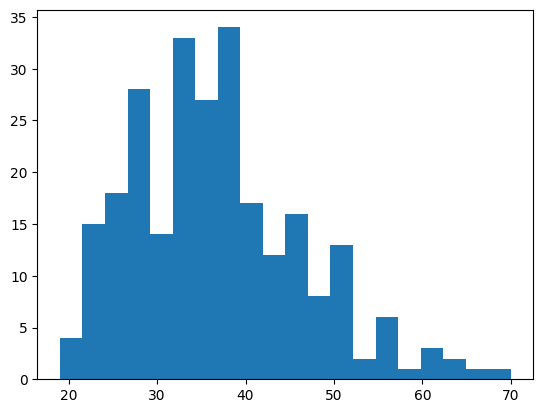

In [ ]:
full_imputetd_data['agea'].hist(bins = 20, grid=False, )

<Axes: >

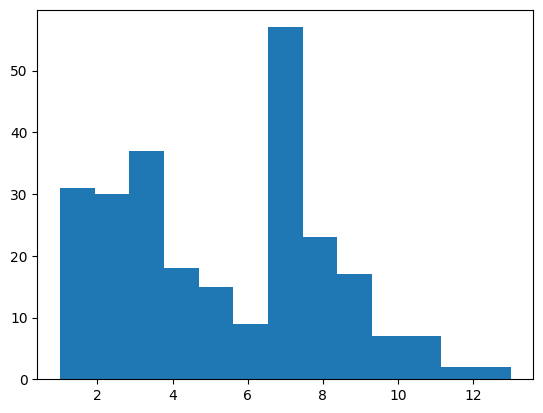

In [ ]:
full_imputetd_data['num_crs'].hist(bins = 13, grid=False)

<Axes: >

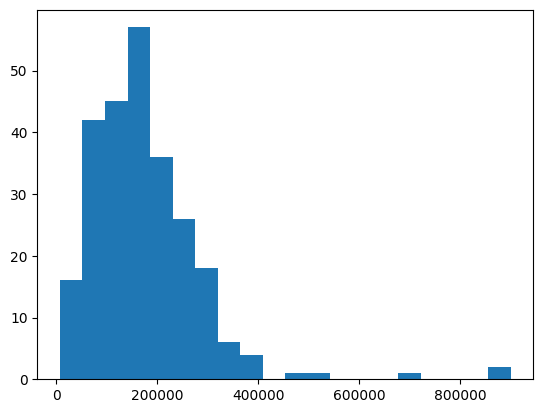

In [ ]:
full_imputetd_data['sal'].hist(grid=False, bins=20)

<Axes: >

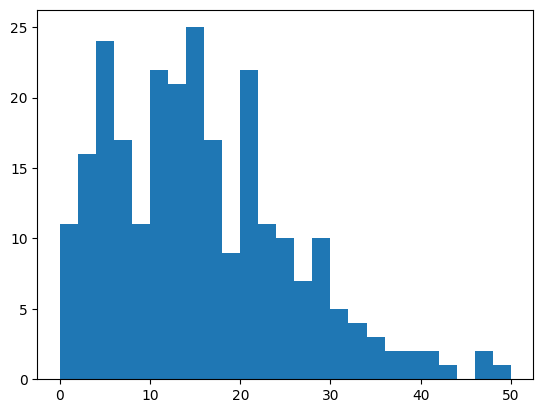

In [ ]:
full_imputetd_data['agewrk'].hist(bins = 25, grid=False, )

<Axes: >

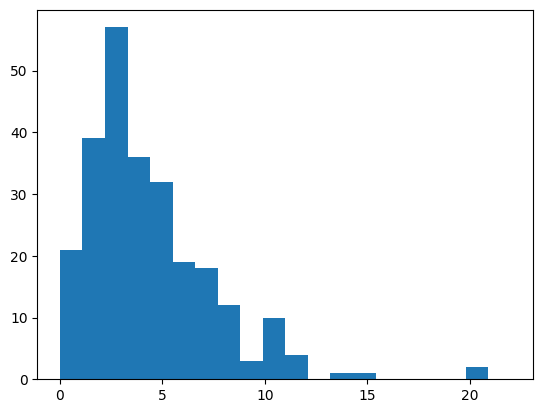

In [ ]:
full_imputetd_data['plcwrk'].hist(bins = 20, grid=False, range=[0, 22])

<Axes: >

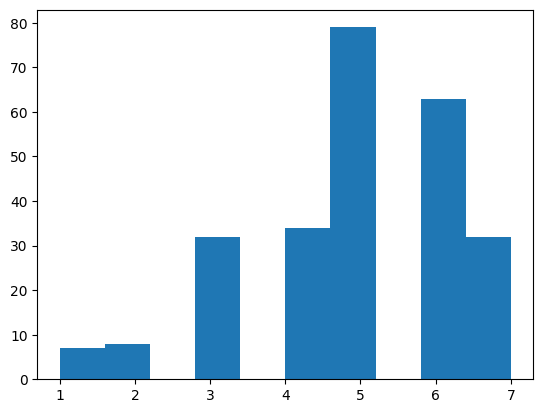

In [ ]:
full_imputetd_data['sat_wrk'].hist(grid=False)

In [ ]:
full_imputetd_data['edu'].value_counts().sort_index()

,count
edu,
2.0,0.392157
3.0,0.392157
4.0,0.392157
5.0,2.745098
6.0,24.705882
7.0,46.666667
8.0,24.705882


In [ ]:
sl = pd.read_excel('/content/расшифровка переменных.xlsx')
sl = sl.set_index('name').to_dict()['Unnamed: 2']

In [ ]:
sl['num_crs'] = 'Количество пройденных курсов'

In [ ]:
d = full_imputetd_data.rename(columns = sl)

In [ ]:
sp = []
# for i in range(1, 15):
#   sp.append('Суждение о мотивации '+str(i))

# for i in range(1, 5):
#   sp.append('Суждение о факторах успеха '+str(i))

for i in range(1, 10):
  sp.append('Суждение о мотивах '+str(i))

array([[<Axes: title={'center': 'Суждение о мотивах 1'}>,
        <Axes: title={'center': 'Суждение о мотивах 2'}>,
        <Axes: title={'center': 'Суждение о мотивах 3'}>],
       [<Axes: title={'center': 'Суждение о мотивах 4'}>,
        <Axes: title={'center': 'Суждение о мотивах 5'}>,
        <Axes: title={'center': 'Суждение о мотивах 6'}>],
       [<Axes: title={'center': 'Суждение о мотивах 7'}>,
        <Axes: title={'center': 'Суждение о мотивах 8'}>,
        <Axes: title={'center': 'Суждение о мотивах 9'}>]], dtype=object)

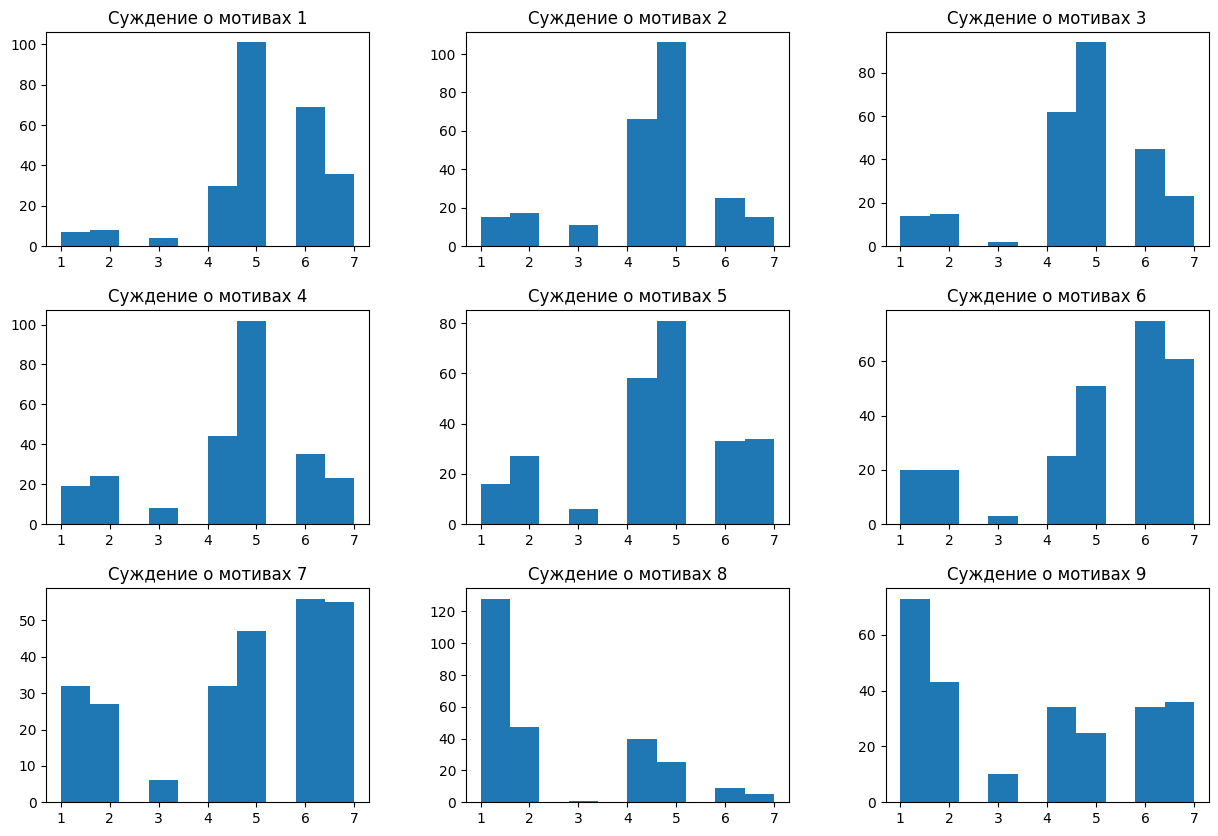

In [ ]:
d[sp].hist(figsize=(15, 10), grid=False, )

In [ ]:
sp

['Суждение о мотивации1',
 'Суждение о мотивации2',
 'Суждение о мотивации3',
 'Суждение о мотивации4',
 'Суждение о мотивации5',
 'Суждение о мотивации6',
 'Суждение о мотивации7',
 'Суждение о мотивации8',
 'Суждение о мотивации9',
 'Суждение о мотивации10',
 'Суждение о мотивации11',
 'Суждение о мотивации12',
 'Суждение о мотивации13',
 'Суждение о мотивации14']

In [ ]:
full_imputetd_data[cat_cols].describe()#.to_excel('inp_int_stat.xlsx')

,gndr,marital_stat,initiative1_employer,initiative2_persona,money_what_employer,money_what_persona,money_what_free_other,is_spec_crs,profwrk
count,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000
mean,1.403922,3.184314,0.317647,0.976471,0.482353,0.423529,0.160784,1.733333,3.482353
std,0.491647,2.567465,0.466477,0.151876,0.500671,0.495089,0.368054,0.443086,1.848249
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000
50%,1.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000,3.000000
75%,2.000000,7.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,5.000000
max,2.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,8.000000


In [ ]:
full_imputetd_data[cat_cols].mode()

,gndr,marital_stat,initiative1_employer,initiative2_persona,money_what_employer,money_what_persona,money_what_free_other,is_spec_crs,profwrk
0,1,1,0,1,0,0,0,2,2
